# Timeline Pipeline Test

Experimental rap/timeline workflow. Parsing creates `df_timeline` and stable IDs only; MEI composition is a separate step where the Verovio rendering view is configured.

In [1]:
from pathlib import Path
import importlib.util
import sys

import pandas as pd
from IPython.display import SVG, display

MODULE_PATH = Path("camat/timeline_backend.py").resolve()
spec = importlib.util.spec_from_file_location("timeline_backend", MODULE_PATH)
timeline = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = timeline
spec.loader.exec_module(timeline)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## Parse To `df_timeline`

This step reads the Humdrum timeline data and creates stable IDs. It does not create MEI.

In [2]:
SOURCE = "https://raw.githubusercontent.com/Computational-Cognitive-Musicology-Lab/MCFlow/main/Humdrum/Eminem_LoseYourself.rap"

parsed = timeline.parse_rap_humdrum_source(SOURCE)
df_timeline = parsed.df_timeline
metadata = parsed.metadata

print(f"rows: {len(df_timeline)}")
print(f"columns: {len(df_timeline.columns)}")
print(f"title: {metadata.get('OTL')}")
print(f"composer: {metadata.get('COM')}")

rows: 718
columns: 33
title: Lose Yourself
composer: Marshall Bruce Mathers III


## Inspect Timeline Data

In [3]:
timeline_cols = [
    "section", "section_role", "measure", "local_onset", "global_onset", "duration",
    "lyric", "ipa", "stress", "tone", "break", "rhyme", "hype",
    "wordpos", "word_id", "xml_id_event", "xml_id_note", "xml_id_syl", "xml_id_annot",
]
display(df_timeline[timeline_cols].head(30))

,section,section_role,measure,local_onset,global_onset,duration,lyric,ipa,stress,tone,break,rhyme,hype,wordpos,word_id,xml_id_event,xml_id_note,xml_id_syl,xml_id_annot
0,Verse1,verse,0,0.00,0.00,0.25,NaN,R,NaN,None,NaN,NaN,None,NaN,NaN,evt-verse1-m000-s0001,NaN,NaN,ann-verse1-m000-s0001
1,Verse1,verse,0,0.25,0.25,0.25,His,hIz,0,None,5,NaN,None,s,w-verse1-0001,evt-verse1-m000-s0002,n-verse1-m000-s0002,syl-verse1-m000-s0002,ann-verse1-m000-s0002
2,Verse1,verse,0,0.50,0.50,0.50,palms,palmz,1,None,NaN,(A,None,s,w-verse1-0002,evt-verse1-m000-s0003,n-verse1-m000-s0003,syl-verse1-m000-s0003,ann-verse1-m000-s0003
3,Verse1,verse,1,0.00,1.00,0.25,are,ar,0,None,NaN,NaN,None,s,w-verse1-0003,evt-verse1-m001-s0004,n-verse1-m001-s0004,syl-verse1-m001-s0004,ann-verse1-m001-s0004
4,Verse1,verse,1,0.25,1.25,0.25,swea-,swɜ,1,None,NaN,B C,None,i,w-verse1-0004,evt-verse1-m001-s0005,n-verse1-m001-s0005,syl-verse1-m001-s0005,ann-verse1-m001-s0005
5,Verse1,verse,1,0.50,1.50,0.50,-ty.,ɾi,0,None,NaN,b),None,t,w-verse1-0004,evt-verse1-m001-s0006,n-verse1-m001-s0006,syl-verse1-m001-s0006,ann-verse1-m001-s0006
6,Verse1,verse,1,1.00,2.00,0.50,Knees,niz,1,None,3,NaN,None,s,w-verse1-0005,evt-verse1-m001-s0007,n-verse1-m001-s0007,syl-verse1-m001-s0007,ann-verse1-m001-s0007
7,Verse1,verse,1,1.50,2.50,0.50,weak.,wik,1,None,NaN,NaN,None,s,w-verse1-0006,evt-verse1-m001-s0008,n-verse1-m001-s0008,syl-verse1-m001-s0008,ann-verse1-m001-s0008
8,Verse1,verse,1,2.00,3.00,0.50,Arms,armz,1,None,2,(A,None,s,w-verse1-0007,evt-verse1-m001-s0009,n-verse1-m001-s0009,syl-verse1-m001-s0009,ann-verse1-m001-s0009
9,Verse1,verse,1,2.50,3.50,0.25,are,ar,0,None,NaN,NaN,None,s,w-verse1-0008,evt-verse1-m001-s0010,n-verse1-m001-s0010,syl-verse1-m001-s0010,ann-verse1-m001-s0010


In [4]:
id_cols = ["xml_id_event", "xml_id_note", "xml_id_syl", "xml_id_annot"]
id_summary = []
for col in id_cols:
    values = df_timeline[col].dropna().astype(str)
    id_summary.append({
        "column": col,
        "non_null": len(values),
        "unique": values.nunique(),
        "duplicates": len(values) - values.nunique(),
    })

display(pd.DataFrame(id_summary))

,column,non_null,unique,duplicates
0,xml_id_event,718,718,0
1,xml_id_note,660,660,0
2,xml_id_syl,660,660,0
3,xml_id_annot,718,718,0


## Compose MEI View

`lyric_info_fields` controls which timeline columns are rendered below the main lyric line. `lyric_info_layout="separate"` gives each field its own verse line and MEI `type`, so the rendered labels and XML stay interpretable without reparsing the source data.

In [5]:
LYRIC_INFO_FIELDS = ["stress", "break", "rhyme"]
# Short labels keep the rendered analysis lines readable.
LYRIC_INFO_LABELS = {"stress": "S", "break": "B", "rhyme": "R"}

mei_text = timeline.timeline_to_mei(
    df_timeline,
    metadata=metadata,
    staff_lines=1,
    show_clef=False,
    note_position="staff",
    note_loc=0,
    main_lyric_verse_n="1",
    lyric_info_fields=LYRIC_INFO_FIELDS,
    lyric_info_labels=LYRIC_INFO_LABELS,
    lyric_info_verse_n="2",
    lyric_info_layout="separate",
    include_annotations=False,
    measures_per_system=1,
)

duplicate_xml_ids = timeline.find_duplicate_mei_xml_ids(mei_text)
display(duplicate_xml_ids)
print(f"duplicate xml:id count: {len(duplicate_xml_ids)}")

,xml_id,count


duplicate xml:id count: 0


## Save MEI

In [6]:
out_dir = Path("exports/timeline")
mei_path = out_dir / "Eminem_LoseYourself.timeline.mei"

timeline.save_timeline_mei(
    df_timeline,
    mei_path,
    metadata=metadata,
    staff_lines=1,
    show_clef=False,
    note_position="staff",
    note_loc=0,
    main_lyric_verse_n="1",
    lyric_info_fields=LYRIC_INFO_FIELDS,
    lyric_info_labels=LYRIC_INFO_LABELS,
    lyric_info_verse_n="2",
    lyric_info_layout="separate",
    include_annotations=False,
    measures_per_system=1,
)

print(mei_path)
print(mei_text[:1600])

exports/timeline/Eminem_LoseYourself.timeline.mei
<?xml version="1.0" encoding="UTF-8"?>
<mei xmlns="http://www.music-encoding.org/ns/mei" meiversion="5.0">
  <meiHead>
    <fileDesc>
      <titleStmt>
        <title>Lose Yourself</title>
      </titleStmt>
      <pubStmt><p>Generated by CAMAT timeline_backend.</p></pubStmt>
    </fileDesc>
    <workList>
      <work>
        <title>Lose Yourself</title>
        <composer>
          <persName>Marshall Bruce Mathers III</persName>
        </composer>
      </work>
    </workList>
  </meiHead>
  <music>
    <body>
      <mdiv>
        <score>
          <scoreDef meter.count="4" meter.unit="4">
            <staffGrp>
              <staffDef n="1" lines="1"/>
            </staffGrp>
          </scoreDef>
          <section xml:id="sec-verse1" label="Verse1" type="verse">
            <measure xml:id="measure-verse1-000" n="0">
              <staff n="1">
                <layer n="1">
                  <rest xml:id="evt-verse1-m000-s0001" du

## Render Generated MEI In Verovio

loaded: True
pages: 1


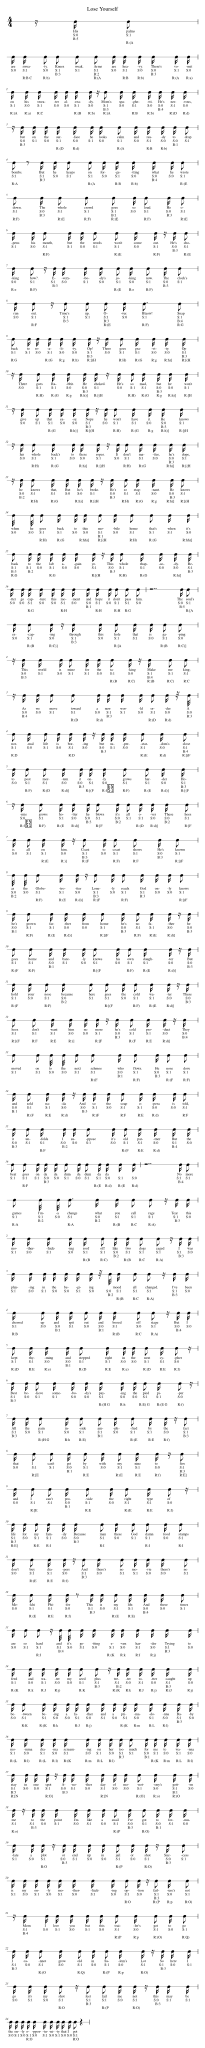

In [7]:
import verovio

tk = verovio.toolkit()
tk.setOptions({
    "inputFrom": "mei",
    "breaks": "encoded",
    "pageWidth": 1500,
    "pageHeight": 2100,
    "scale": 35,
    "adjustPageHeight": True,
    "lyricSize": 3.0,
    "lyricVerseCollapse": True,
})

loaded = tk.loadData(mei_text)
page_count = tk.getPageCount()
print(f"loaded: {loaded}")
print(f"pages: {page_count}")

display(SVG(tk.renderToSVG(1)))

In [8]:
if page_count > 1:
    display(SVG(tk.renderToSVG(2)))